In [1]:
!pip install diffusers
!pip install open_clip_torch 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00


In [2]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
import os
import torch
import numpy as np
from PIL import Image
import open_clip
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# Define parameters
model_id = "/kaggle/input/stable-diffusion-v2/pytorch/0/1"
prompts = [
    "the scarab from the moon knight marvel series. hieroglyphs substance 3 d designer. rendered in marmoset toolbag.",
    "close - up shot portrait, imogen poots as virtuous! divinity cleric, pastel colours, ascendant goddess, octane render, unreal engine render, matte painting concept art, fanart artstation, by jesper ejsing and artgerm and charlie bowater and rhads and lois van baarle and ilya kuvshinov and rossdraws.",
    "a majestic firedragon creature fighting a fighter jet, 8 k, magic realism, beautiful composition.",
    "anya taylor - joy emma watson as nuragic warrior, long braided blond hair, meadow background, intricate, highly detailed, digital painting, artstation, concept art, sharp focus, illustration, art by aleksi briclot and raphael lacoste and magali villeneuve and bouguereau.",
    "a corgi casting a magic spell, d & d character art, hyperrealistic, extremely detailed, fantasy, digital illustration by artgerm and greg rutkowski, trending on artstation, masterpiece, award - winning.",
    "an striking!! render of a middle aged woman with auburn hair and a white veil on her head wearing a green dress sitting in front of an open window, an ambient occlusion render, featured on zbrush central, hyper realistic art, neural pointillism, houdini, zbrush, warm earth tones, natural light, oil painting, strong brushwork.",
    "photo cartoon illustration comic manga painting of space environement : 6 fantasy environement, digital painting, volumetric lighting by feng zhu, 3 d alejandro alvarez alena aenami artworks in 4 k beeple, by thomas kinkade hearstone league of legends dofus overwatch.",
    "a majestic firedragon king creature fighting a fighter jet, rockets and explosions, 8 k, magic realism, beautiful composition.",
    "photo cartoon illustration comic manga painting of jungle environement : 6 fantasy environement, digital painting, volumetric lighting by feng zhu, 3 d alejandro alvarez alena aenami artworks in 4 k beeple, by thomas kinkade hearstone league of legends dofus overwatch.",
    "frank dillane in whitechapel, 1 8 8 0 s, steampunk, alley, streets, walter sickert, hyper realistic, artstation, illustration, digital paint, matte paint, vivid colors, detailed and intricate environment.",
    "cyberpunk sniper by josan gonzalez splash art graphic design color splash high contrasting art, fantasy, highly detailed, art by greg rutkowski."
]

# Create output directory
output_dir = "/kaggle/working/generated_images"
os.makedirs(output_dir, exist_ok=True)

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Stable Diffusion model
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

# Load OpenCLIP model
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-16', pretrained='datacomp_xl_s13b_b90k')
model.eval().to(device)

# Generate images and calculate similarity
similarity_results = []

for idx, prompt in enumerate(prompts, start=1):
    # Generate image
    image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
    image.save(os.path.join(output_dir, f"generated_image_{idx}.png"))

    # Calculate similarity
    with torch.no_grad():
        # Process image
        image_input = preprocess(image).unsqueeze(0).to(device)
        image_features = model.encode_image(image_input).float()
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # Process text
        text_tokens = open_clip.tokenize([prompt]).to(device)
        text_features = model.encode_text(text_tokens).float()
        text_features /= text_features.norm(dim=-1, keepdim=True)

        # Calculate cosine similarity
        similarity = (text_features @ image_features.T).cpu().item()
        similarity_results.append((prompt, similarity))

# Save similarity results to a text file
similarity_file_path = os.path.join(output_dir, "similarity_results.txt")
with open(similarity_file_path, "w") as f:
    for prompt, similarity in similarity_results:
        f.write(f"Prompt: {prompt}\nSimilarity: {similarity:.4f}\n\n")

print(f"All images have been generated and saved to {output_dir}")
print(f"Similarity results have been saved to {similarity_file_path}")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /kaggle/input/stable-diffusion-v2/pytorch/0/1/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


open_clip_pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

All images have been generated and saved to /kaggle/working/generated_images
Similarity results have been saved to /kaggle/working/generated_images/similarity_results.txt


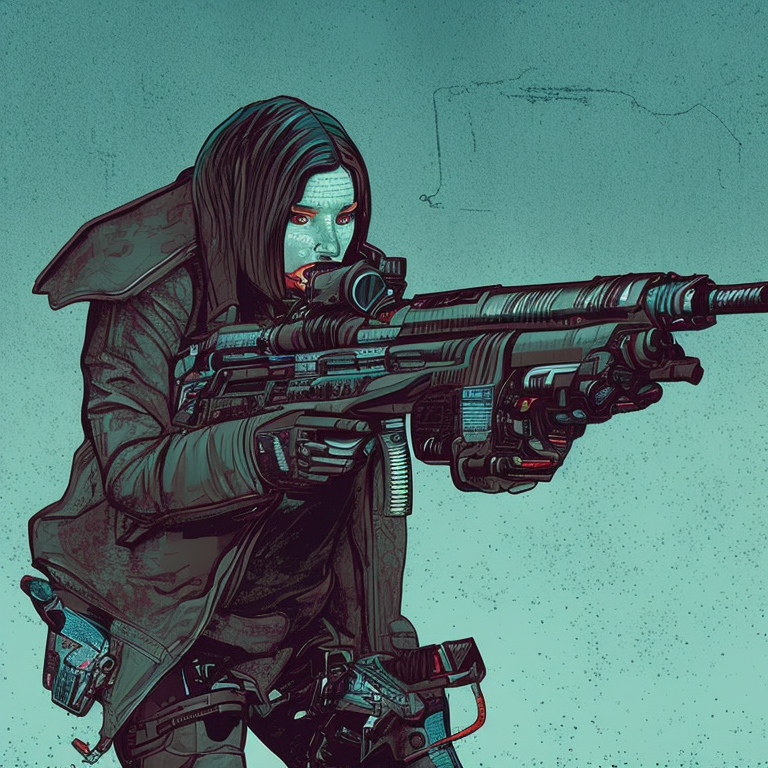

In [4]:
image